In [1]:
import xarray as xr
import numpy as np
from subs1_utils import *
import matplotlib.pyplot as plt

import torch
import torch_harmonics.distributed as dist
import torch_harmonics as th

import xesmf as xe


In [2]:
def cosine_taper(lat_deg, lat_min=10, lat_max=20):
    lat = np.abs(lat_deg)
    w = np.zeros_like(lat, dtype=float)
    inside = lat <= lat_min
    taper = (lat > lat_min) & (lat < lat_max)
    w[inside] = 1.0
    w[taper] = 0.5*(1 + np.cos(np.pi*(lat[taper]-lat_min)/(lat_max-lat_min)))
    return w

def vertical_profile_tropics(kmax=26, peak=8, sigma=3.5):
    k_idx = np.arange(kmax)
    vert = np.exp(-0.5*((k_idx - peak)/sigma)**2)
    return vert / vert.sum()

def vertical_profile_midlat(kmax=26, decay=0.15):
    k_idx = np.arange(kmax)
    vert = np.exp(-decay*(kmax-1 - k_idx))
    return vert / vert.sum()

#def blend_weights(w_trop, w_mid):
#    total = w_trop + w_mid
#    total[total == 0] = 1.0
#    return w_trop/total, w_mid/total

def plot_vertical_slice(heat3d, lats, kmax, lon_idx=100, title="Heating cross-section"):
    k_idx = np.arange(kmax)
    heating_slice = heat3d[:, :, lon_idx].numpy()
    plt.figure(figsize=(10,5))
    plt.pcolormesh(lats, k_idx, heating_slice, shading='auto', cmap='bwr')
    plt.gca().invert_yaxis()
    plt.colorbar(label="Heating (K/day)")
    plt.xlabel("Latitude")
    plt.ylabel("Vertical level k (0=top)")
    plt.title(title)
    plt.show()

In [3]:
def tropical_weight(lats, trop_lat=10, taper_to=20):
    """
    Cosine taper for tropical heating.

    Parameters
    ----------
    lats : np.ndarray
        1D latitude array (north-to-south)
    trop_lat : float
        Half-width of tropical zone (degrees)
    taper_to : float
        Latitude where tropical heating tapers to zero (degrees)

    Returns
    -------
    w_trop : np.ndarray
        Tropical horizontal weights (0-1)
    """
    w_trop = np.zeros_like(lats, dtype=float)
    mask = np.abs(lats) <= taper_to
    x = np.clip((np.abs(lats[mask]) - trop_lat) / (taper_to - trop_lat), 0, 1)
    w_trop[mask] = np.cos(0.5 * np.pi * x)**2  # 1 at tropics, 0 at taper_to
    return w_trop

def blend_vertical_profiles(heat_base, vert_trop_t, vert_mid_t, lats):
    """
    Blend tropical and midlatitude vertical profiles using horizontal weights.

    Parameters
    ----------
    heat_base : torch.Tensor (nlat, nlon)
        Horizontal heating field
    vert_trop_t : torch.Tensor (kmax,1,1)
        Tropical vertical profile (top-heavy)
    vert_mid_t : torch.Tensor (kmax,1,1)
        Midlatitude vertical profile (bottom-heavy)
    lats : np.ndarray
        1D latitude array

    Returns
    -------
    heat3d : torch.Tensor (kmax, nlat, nlon)
    """
    jmax, imax = heat_base.shape

    # Horizontal weights
    w_trop = tropical_weight(lats)
    w_mid = northern_midlat_weight(lats)

    # Normalize weights
    total = w_trop + w_mid
    total[total == 0] = 1.0
    w_trop /= total
    w_mid /= total

    # Convert to Torch tensors
    w_trop_t = torch.from_numpy(w_trop).float().view(1, jmax, 1)
    w_mid_t = torch.from_numpy(w_mid).float().view(1, jmax, 1)

    # Broadcast heat_base
    heat_base_t = heat_base.unsqueeze(0)  # (1, nlat, nlon)

    # Weighted blend
    heat3d = heat_base_t * (w_trop_t * vert_trop_t + w_mid_t * vert_mid_t)
    return heat3d

def northern_midlat_weight(lats, trop_lat=10, midlat_max=50):
    """
    Cosine taper for midlatitude heating in northern hemisphere.

    Parameters
    ----------
    lats : np.ndarray
        1D latitude array (north-to-south)
    trop_lat : float
        Latitude where midlat heating starts to rise
    midlat_max : float
        Latitude where midlat heating goes to zero

    Returns
    -------
    w_mid : np.ndarray
        Midlatitude horizontal weights (0-1)
    """
    w_mid = np.zeros_like(lats, dtype=float)

    # Northern hemisphere only
    nh_mask = lats >= trop_lat  # northern latitudes
    x = (lats[nh_mask] - trop_lat) / (midlat_max - trop_lat)  # 0 at trop_lat, 1 at midlat_max
    x = np.clip(x, 0, 1)

    # Cosine squared taper: max at trop_lat, 0 at midlat_max
    w_mid[nh_mask] = np.cos(0.5 * np.pi * x)**2
    return w_mid

In [4]:
import numpy as np

def northern_midlat_weight(lats, trop_lat=10, midlat_max=50):
    """
    Cosine taper for midlatitude heating, applied only in the northern hemisphere
    and cut off at midlat_max.

    Parameters
    ----------
    lats : np.ndarray
        1D latitude array (degrees, north positive)
    trop_lat : float
        Latitude where tropical heating ends (degrees)
    midlat_max : float
        Maximum latitude for midlatitude heating (degrees)

    Returns
    -------
    w_mid : np.ndarray
        1D weights for midlatitude heating (0-1)
    """
    w_mid = np.zeros_like(lats, dtype=float)

    # Only consider latitudes above tropical region
    nh_mask = (lats >= trop_lat) & (lats <= midlat_max)

    # Cosine taper from trop_lat → midlat_max
    w_mid[nh_mask] = np.cos(
        0.5 * np.pi * (lats[nh_mask] - trop_lat) / (midlat_max - trop_lat)
    )**2

    return w_mid


In [5]:
def normalize_weights(w_trop, w_mid):
    """Normalize horizontal weights so w_trop + w_mid <= 1."""
    total = w_trop + w_mid
    total[total == 0] = 1.0  # avoid divide by zero
    return w_trop / total, w_mid / total

In [6]:
def generate_cluster_precip(prec_clusters, heat_clim, dlatlon,
                            lat_bounds=(27,35), lon_bounds=(100,140)):
    """
    Generate cluster-specific horizontal precipitation fields on Gaussian grid,
    masked to a region (e.g., ANA), without converting to heating.

    Parameters
    ----------
    prec_clusters : xarray.Dataset
        Precipitation anomalies grouped by clusters.
        Expected variable: 'prec', dimension 'clusters'.
    heat_clim : np.ndarray
        Climatology precipitation (Gaussian grid) shape (nlat,nlon)
    dlatlon : xarray.Dataset
        Gaussian grid definition with lat/lon coordinates
    lat_bounds : tuple
        Latitude bounds for the region mask
    lon_bounds : tuple
        Longitude bounds for the region mask

    Returns
    -------
    cluster_precip_list : list of np.ndarray
        List of 2D precipitation arrays (nlat,nlon) for each cluster
    """
    cluster_precip_list = []
    n_clusters = len(prec_clusters['clusters'])

    for c in range(n_clusters):
        # Select cluster anomaly
        rain_anom = prec_clusters['prec'].sel(clusters=c) * 10  # scale if needed

        # Apply regional mask
        lat_cond = (rain_anom['lat'] <= lat_bounds[1]) & (rain_anom['lat'] >= lat_bounds[0])
        lon_cond = (rain_anom['lon'] >= lon_bounds[0]) & (rain_anom['lon'] <= lon_bounds[1])
        rain_masked = xr.where(lat_cond & lon_cond, rain_anom, 0.0)

        # Regrid anomaly to Gaussian grid
        regridder = xe.Regridder(rain_masked, dlatlon, 'bilinear')
        rain_gauss = regridder(rain_masked).values

        # Total precipitation = climatology + anomaly
        total_precip = heat_clim + rain_gauss
        cluster_precip_list.append(total_precip)

    return cluster_precip_list

In [7]:
def generate_cluster_heating_from_precip(cluster_precip_list,
                                         vert_trop_t, vert_mid_t,
                                         w_trop_t, w_mid_t,
                                         kmax=26):
    """
    Generate 3D heating arrays for each cluster from precipitation fields,
    applying vertical structure and latitude weighting.

    Parameters
    ----------
    cluster_precip_list : list of np.ndarray
        List of 2D precipitation arrays (nlat,nlon) for each cluster (climatology + anomaly)
    vert_trop_t : torch.Tensor
        Tropics vertical profile (kmax,1,1)
    vert_mid_t : torch.Tensor
        Midlat vertical profile (kmax,1,1)
    w_trop_t : torch.Tensor
        Latitude weights for tropics (1,nlat,1)
    w_mid_t : torch.Tensor
        Latitude weights for midlat (1,nlat,1)
    kmax : int
        Number of vertical levels

    Returns
    -------
    cluster_heat3d_list : list of torch.Tensor
        List of 3D heating arrays (kmax, nlat, nlon) for each cluster
    """
    # Latent heating conversion factor (K/day per mm/day)
    Lv = 2.5e6
    rhow = 1000.0
    Cp = 1005.0
    Ps = 101325.0
    grav = 9.8
    beta = (Lv*rhow/Cp)*(grav/Ps)/(1000*86400.0)

    dsht = dist.DistributedRealSHT(jmax, imax, lmax=mw, mmax=zw, grid="legendre-gauss", csphase=False)
    disht = dist.DistributedInverseRealSHT(jmax, imax, lmax=mw, mmax=zw, grid="legendre-gauss", csphase=False)

    cluster_heat3d_list = []

    for precip in cluster_precip_list:
        # Convert total precipitation to heating
        heat_base = torch.from_numpy(precip.astype(np.float32)) * beta
        
        # Apply spectral filtering
        heat_spec = dsht(heat_base)
        heat_spec_t = disht(heat_spec)

        # Build 3D heating array
        nlat, nlon = heat_base.shape
        heat3d = torch.zeros((kmax, nlat, nlon), dtype=torch.float32)
        for k in range(kmax):
            #heat3d[k,:,:] = heat_spec_t * (w_trop_t * vert_trop_t[k] + w_mid_t * vert_mid_t[k])
            heat3d[k,:,:] = heat_spec_t * (w_mid_t * vert_mid_t[k])
        cluster_heat3d_list.append(heat3d)

    return cluster_heat3d_list

In [8]:
def plot_horizontal_heating(cluster_heat3d_list, lats, lons, level=0, cmap='bwr'):
    """
    Plot horizontal heating fields for multiple clusters at a given vertical level.

    Parameters
    ----------
    cluster_heat3d_list : list of torch.Tensor
        List of 3D heating arrays (kmax, nlat, nlon)
    lats : np.ndarray
        1D latitude array
    lons : np.ndarray
        1D longitude array
    level : int
        Vertical level to plot (0 = top of atmosphere)
    cmap : str
        Colormap
    """
    n_clusters = len(cluster_heat3d_list)
    nrows = 2
    ncols = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for i in range(n_clusters):
        heat_slice = cluster_heat3d_list[i][level, :, :].cpu().numpy() if isinstance(cluster_heat3d_list[i], torch.Tensor) else cluster_heat3d_list[i][level, :, :]
        pcm = axes[i].pcolormesh(lons, lats, heat_slice, shading='auto', cmap=cmap)
        axes[i].set_title(f'Cluster {i}')
        axes[i].set_xlabel('Longitude')
        axes[i].set_ylabel('Latitude')

    # Shared colorbar
    fig.colorbar(pcm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label='Heating (K/day)')
    plt.suptitle(f'Horizontal Heating at Level {level}', fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

    # Confirm clusters differ
    for i in range(n_clusters):
        for j in range(i+1, n_clusters):
            diff = cluster_heat3d_list[i][level,:,:] - cluster_heat3d_list[j][level,:,:]
            max_diff = torch.max(torch.abs(diff)).item() if isinstance(diff, torch.Tensor) else np.max(np.abs(diff))
            print(f"Max difference between cluster {i} and {j}: {max_diff:.3e}")

In [9]:
def plot_vertical_profiles(vert_trop_t, vert_mid_t):
    """
    Plot vertical profiles of heating weights for tropics and midlat.

    Parameters
    ----------
    vert_trop_t : torch.Tensor
        Tropics vertical profile (kmax,1,1)
    vert_mid_t : torch.Tensor
        Midlat vertical profile (kmax,1,1)
    """
    kmax = vert_trop_t.shape[0]
    levels = np.arange(kmax)

    # Convert to numpy if tensors
    vert_trop = vert_trop_t.squeeze().cpu().numpy() if isinstance(vert_trop_t, torch.Tensor) else vert_trop_t.squeeze()
    vert_mid = vert_mid_t.squeeze().cpu().numpy() if isinstance(vert_mid_t, torch.Tensor) else vert_mid_t.squeeze()

    plt.figure(figsize=(6,6))
    plt.plot(vert_trop, levels, label='Tropics', marker='o')
    plt.plot(vert_mid, levels, label='Midlat (N-Hem)', marker='s')
    plt.gca().invert_yaxis()  # k=0 is top of atmosphere
    plt.xlabel('Weight')
    plt.ylabel('Vertical level k (0=top)')
    plt.title('Vertical Profiles of Heating Weights')
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
### Ouput Path ####
fullpath =  '/data/esplab/kpegion/projects/AGCM/MultiThread_Model/preprocess__zw_63__kmax_26_JJA_1979-2023/'

# ANA Region
lat_bounds=(27,35)
lon_bounds=(100,140)

cluster_filestub=['cluster1_ANA_1979-2023','cluster2_ANA_1979-2023','cluster3_ANA_1979-2023','cluster4_ANA_1979-2023']

# ------------------------------
# 2. Set up Gaussian grid
# ------------------------------
jmax = 96
imax = 192
kmax = 26
mw = 63
zw = 63

# Use existing precompute_latitudes function
cost_lg, wlg, lats_rad = precompute_latitudes(jmax)
lats = 90 - 180*lats_rad/np.pi
lons = np.linspace(0.0, 360.0-360.0/imax, imax)
dlatlon = xr.Dataset({"lat": lats, "lon": lons})
delsig, si, sl, sikap, slkap, cth1, cth2, r1b, r2b = bscst(kmax)

In [11]:
print(lats[0], lats[-1])  # northmost, southmost

88.57216851400727 -88.57216851400727


In [12]:
# ------------------------------
# 3a. Horizontal heating Climatology
# ------------------------------
#heat_base = np.ones((jmax, imax))  # placeholder horizontal field

ftemp = 'http://psl.noaa.gov/thredds/dodsC/Datasets/cmap/enh/precip.mon.mean.nc'
Dprec = xr.open_dataset(ftemp, autoclose=True).sel(time=slice('1979-01-01','2023-12-31'))

# Climatology
prec_clim = Dprec.precip.groupby('time.month').mean(dim='time')
prec_clim_jja = (prec_clim[5] + prec_clim[6] + prec_clim[7]) / 3.0  # JJA

# Regrid to Gaussian grid
regridder_rain_clim = xe.Regridder(prec_clim_jja, dlatlon, 'bilinear')
heat_clim = regridder_rain_clim(prec_clim_jja).values  # numpy array

In [13]:
heat_clim

array([[0.        , 0.854637  , 0.8786052 , ..., 0.941746  , 0.9240184 ,
        0.8783809 ],
       [0.        , 0.7889328 , 0.80325437, ..., 0.83315337, 0.81869185,
        0.7971238 ],
       [0.        , 0.7933101 , 0.81842256, ..., 0.7672336 , 0.7656216 ,
        0.76712936],
       ...,
       [0.        , 0.59710205, 0.59143925, ..., 0.62487185, 0.616684  ,
        0.6094649 ],
       [0.        , 0.65098083, 0.64240766, ..., 0.6516598 , 0.64621645,
        0.64260656],
       [0.        , 0.7587514 , 0.7469123 , ..., 0.7113619 , 0.7056202 ,
        0.7014454 ]], dtype=float32)

In [14]:
ftemp_anoms='/data/esplab/psinghai/projects/obs_seus/Review/Submit_paper_plots/heating_files/era5_prec_pos_1979-2023.nc'
Dprec_anoms = xr.open_dataset(ftemp_anoms,autoclose=True)
prec_clusters=Dprec_anoms.groupby('clusters').mean().compute()

cluster_precip_list = generate_cluster_precip(
    prec_clusters=prec_clusters,
    heat_clim=heat_clim,
    dlatlon=dlatlon,
    lat_bounds=lat_bounds,
    lon_bounds=lon_bounds
)

print("Number of clusters:", len(cluster_precip_list))
print("Shape of cluster 0 precipitation:", cluster_precip_list[0].shape)  # (nlat,nlon)

Number of clusters: 4
Shape of cluster 0 precipitation: (96, 192)


In [15]:
# --- Compute horizontal weights ---
w_trop = tropical_weight(lats, trop_lat=0, taper_to=0)
w_mid  = northern_midlat_weight(lats, trop_lat=0, midlat_max=50)

# --- Normalize weights ---
w_trop_norm, w_mid_norm = normalize_weights(w_trop, w_mid)

# --- Convert to torch for 3D heating ---
w_trop_t = torch.from_numpy(w_trop_norm).float().view(1, jmax, 1)
w_mid_t  = torch.from_numpy(w_mid_norm).float().view(1, jmax, 1)


In [16]:
# ------------------------------
# 5. Vertical profiles
# ------------------------------
vert_trop_t = torch.from_numpy(vertical_profile_tropics(kmax)).float().view(kmax, 1, 1)
vert_mid_t  = torch.from_numpy(vertical_profile_midlat(kmax)).float().view(kmax, 1, 1)

In [17]:
# cluster_precip_list obtained from previous function
cluster_heat3d_list = generate_cluster_heating_from_precip(
    cluster_precip_list=cluster_precip_list,
    vert_trop_t=vert_trop_t,
    vert_mid_t=vert_mid_t,
    w_trop_t=w_trop_t,
    w_mid_t=w_mid_t,
    kmax=kmax
)

print("Number of clusters:", len(cluster_heat3d_list))
print("Shape of cluster 0 heating:", cluster_heat3d_list[0].shape)  # (kmax, nlat, nlon)

Number of clusters: 4
Shape of cluster 0 heating: torch.Size([26, 96, 192])


In [18]:
fullpath

'/data/esplab/kpegion/projects/AGCM/MultiThread_Model/preprocess__zw_63__kmax_26_JJA_1979-2023/'

In [19]:
for c,filestub in zip(cluster_heat3d_list,cluster_filestub):
    ofname=fullpath+'heat.ggrid_'+filestub+'.pt'
    torch.save(c,ofname)

In [20]:
for c in cluster_heat3d_list:
    foofoo = torch.transpose(c*86400, 0, 1)
    print(c.shape)
    print(f"max anomaly:", float(foofoo.min()),float(foofoo.max()))

torch.Size([26, 96, 192])
max anomaly: -0.383677214384079 0.6828770041465759
torch.Size([26, 96, 192])
max anomaly: -0.14059504866600037 1.0728319883346558
torch.Size([26, 96, 192])
max anomaly: -0.3394677937030792 0.8787233233451843
torch.Size([26, 96, 192])
max anomaly: -0.18764087557792664 0.6853981018066406


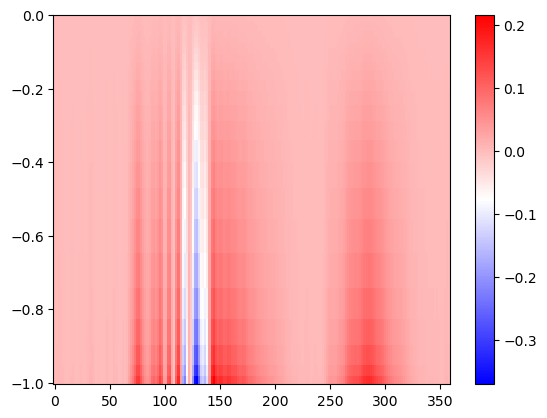

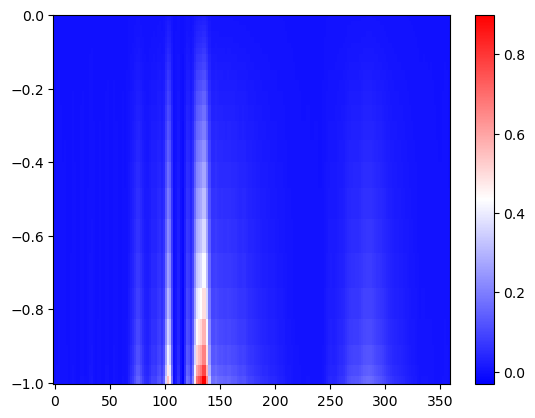

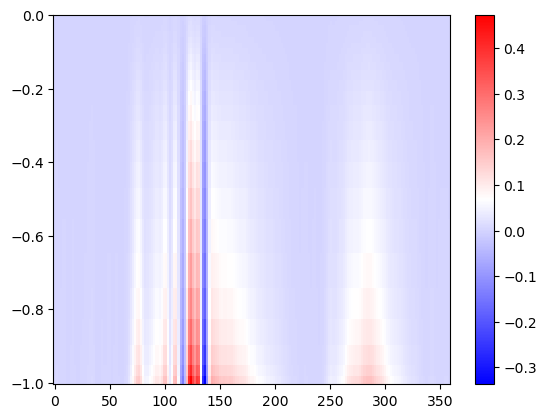

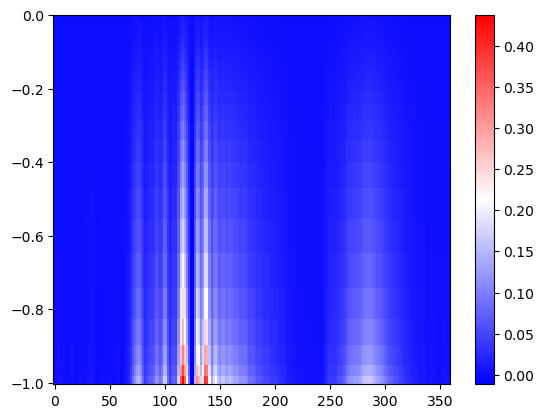

In [21]:
for c in cluster_heat3d_list:
    plt.figure()
    Lev,Lon = np.meshgrid(-sl,lons)
    heating = c[:,30,:]*86400
    foofoo = torch.transpose(heating, 0, 1)
    plt.pcolormesh(Lon, Lev, foofoo, cmap='bwr')
    plt.colorbar()

plot_horizontal_heating(cluster_heat3d_list, lats=dlatlon['lat'].values, lons=dlatlon['lon'].values, level=kmax-1)

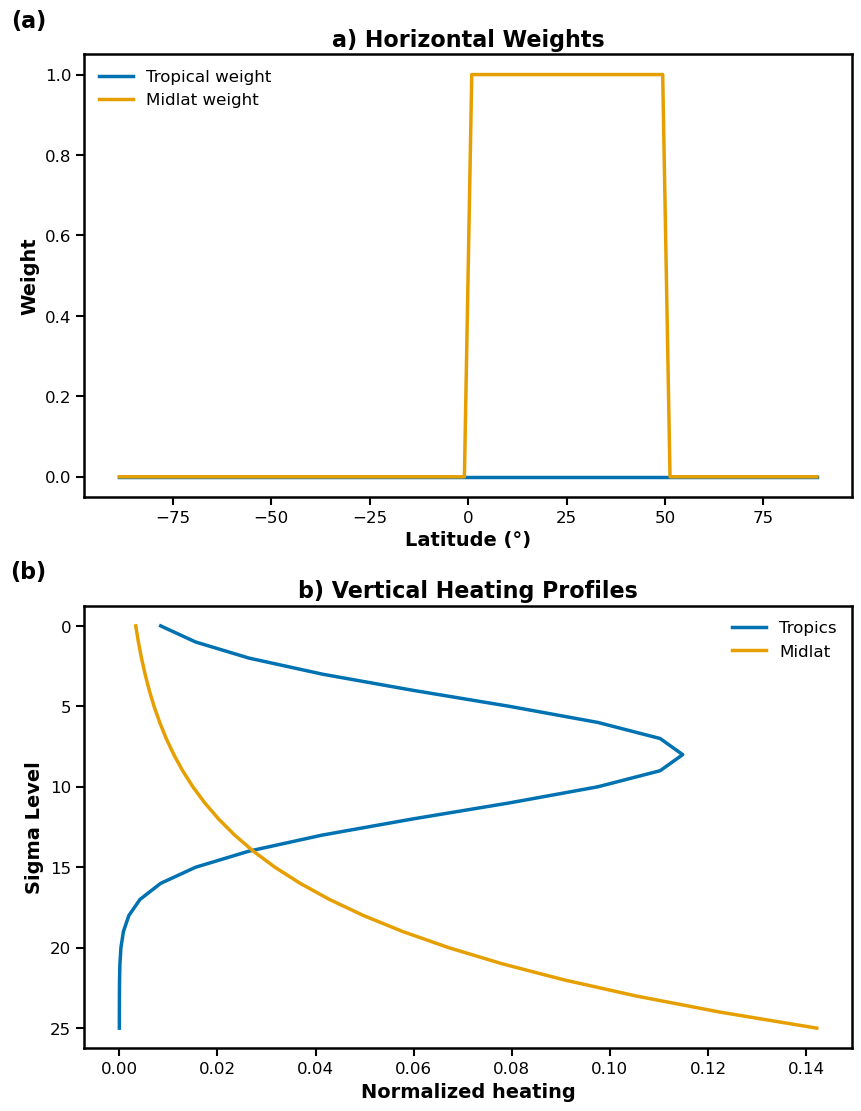

In [22]:
# Define colorblind-friendly palette
colors = ["#0072B2", "#E69F00"]  # blue, dark orange

# Normalize so each sums to 1
vert_trop_t = vert_trop_t / vert_trop_t.sum()
vert_mid_t  = vert_mid_t / vert_mid_t.sum()

# --- Create figure ---
fig, axes = plt.subplots(
    2, 1, figsize=(8.5, 11), constrained_layout=True
)

# --- Common styling function ---
def style_axes(ax):
    ax.tick_params(labelsize=12, width=1.5, length=6, direction="out")
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

# --- Panel 1: Horizontal Weights ---
ax = axes[0]
ax.plot(lats, w_trop_t.squeeze().numpy(), label="Tropical weight", lw=2.5, color=colors[0])
ax.plot(lats, w_mid_t.squeeze().numpy(), label="Midlat weight", lw=2.5, color=colors[1])
ax.set_xlabel("Latitude (°)", fontsize=14, weight="bold")
ax.set_ylabel("Weight", fontsize=14, weight="bold")
ax.legend(frameon=False, fontsize=12)
ax.set_title("a) Horizontal Weights", fontsize=16, weight="bold")
ax.text(-0.05, 1.05, "(a)", transform=ax.transAxes,
        fontsize=16, fontweight="bold", va="bottom", ha="right")
style_axes(ax)

# --- Panel 2: Vertical Profiles ---
ax = axes[1]
ax.plot(
    vert_trop_t.squeeze().numpy(),
    np.arange(kmax), label="Tropics", lw=2.5, color=colors[0]
)
ax.plot(
    vert_mid_t.squeeze().numpy(),
    np.arange(kmax), label="Midlat", lw=2.5, color=colors[1]
)
ax.invert_yaxis()
ax.set_xlabel("Normalized heating", fontsize=14, weight="bold")
ax.set_ylabel("Sigma Level", fontsize=14, weight="bold")
ax.legend(frameon=False, fontsize=12)
ax.set_title("b) Vertical Heating Profiles", fontsize=16, weight="bold")
ax.text(-0.05, 1.05, "(b)", transform=ax.transAxes,
        fontsize=16, fontweight="bold", va="bottom", ha="right")
style_axes(ax)

# --- Save high-quality output ---
plt.savefig("weights_profiles.pdf", dpi=300, bbox_inches="tight")  # vector format
plt.savefig("weights_profiles.png", dpi=600, bbox_inches="tight") # high-res raster
plt.show()
plt.show()

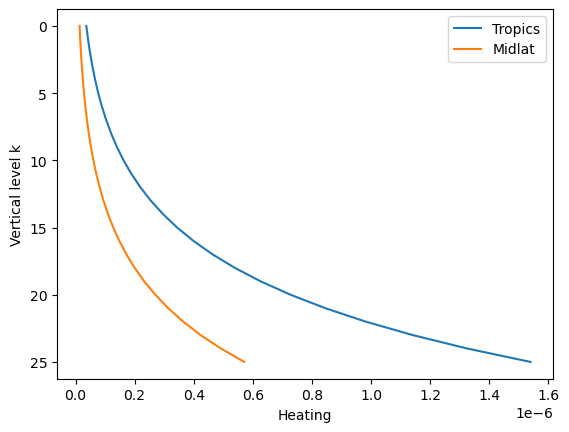

In [23]:
heat3d=cluster_heat3d_list[0]

# Pick a tropical latitude and a midlatitude
lat_idx_trop = np.argmin(np.abs(lats - 0))    # near 0°N
lat_idx_mid  = np.argmin(np.abs(lats - 30))   # ~30°N

plt.plot(heat3d[:, lat_idx_trop, :].mean(dim=1).numpy(), np.arange(kmax), label="Tropics")
plt.plot(heat3d[:, lat_idx_mid, :].mean(dim=1).numpy(), np.arange(kmax), label="Midlat")
plt.gca().invert_yaxis()
plt.xlabel("Heating")
plt.ylabel("Vertical level k")
plt.legend()
plt.show()

import matplotlib.pyplot as plt
import torch
import numpy as np

def debug_vertical_profiles(lats, vert_trop_t, vert_mid_t, w_trop_t, w_mid_t, heat3d=None):
    """
    Plot vertical profiles and blended heating for tropics, overlap, and midlatitudes.

    Parameters
    ----------
    lats : np.ndarray
        1D latitude array (north-to-south)
    vert_trop_t : torch.Tensor
        Tropical vertical profile (kmax,1,1)
    vert_mid_t : torch.Tensor
        Midlatitude vertical profile (kmax,1,1)
    w_trop_t : torch.Tensor
        Horizontal weights for tropics (1,nlat,1)
    w_mid_t : torch.Tensor
        Horizontal weights for midlat (1,nlat,1)
    heat3d : torch.Tensor or np.ndarray, optional
        Blended 3D heating (kmax,nlat,nlon)
    """
    kmax = vert_trop_t.shape[0]

    # Select example latitudes
    lat_examples = [0, 15, 35]  # tropics, overlap, midlat
    labels = ["Tropics (~0°)", "Overlap (~15°)", "Midlat (~35°)"]

    plt.figure(figsize=(10,6))

    for i, lat_val in enumerate(lat_examples):
        # Find nearest latitude index
        lat_idx = np.argmin(np.abs(lats - lat_val))

        # Horizontal weights at this latitude
        w_trop = w_trop_t[0, lat_idx, 0].item()
        w_mid  = w_mid_t[0, lat_idx, 0].item()

        # Weighted vertical profiles
        blended_profile = w_trop * vert_trop_t[:,0,0] + w_mid * vert_mid_t[:,0,0]

        plt.plot(blended_profile.numpy(), range(kmax), label=f"{labels[i]} (w_trop={w_trop:.2f}, w_mid={w_mid:.2f})")

        # Overlay actual 3D heating if provided
        if heat3d is not None:
            if isinstance(heat3d, torch.Tensor):
                heat_profile = heat3d[:, lat_idx, :].mean(dim=1).numpy()
            else:
                heat_profile = heat3d[:, lat_idx, :].mean(axis=1)

            plt.plot(heat_profile, range(kmax), "--", label=f"{labels[i]} heat3d")

    plt.gca().invert_yaxis()  # k=0 = top
    plt.xlabel("Heating / Weighted Profile")
    plt.ylabel("Vertical level k (0=top)")
    plt.title("Debug: Vertical Profiles and Blended Heating")
    plt.legend()
    plt.grid(True)
    plt.show()


debug_vertical_profiles(
    lats=lats,
    vert_trop_t=vert_trop_t,
    vert_mid_t=vert_mid_t,
    w_trop_t=w_trop_t,
    w_mid_t=w_mid_t,
    heat3d=heat3d*86400
)

In [24]:
def plot_lat_vs_vertical(lats, heat3d, title="Blended Heating (K/day)"):
    """
    Plot 2D latitude vs vertical level of heating.

    Parameters
    ----------
    lats : np.ndarray
        1D latitude array (north-to-south)
    heat3d : torch.Tensor
        3D heating array (kmax, nlat, nlon)
    title : str
        Plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np

    kmax, nlat, nlon = heat3d.shape

    # Average over longitude
    heat_lat = heat3d.mean(dim=2).numpy()  # shape: (kmax, nlat)

    # Plot
    plt.figure(figsize=(10,6))
    plt.pcolormesh(lats, np.arange(kmax), heat_lat, shading='auto', cmap='bwr')
    plt.gca().invert_yaxis()  # k=0 = top
    plt.colorbar(label="Heating (K/day)")
    plt.xlabel("Latitude")
    plt.ylabel("Vertical level k (0=top)")
    plt.title(title)
    plt.show()


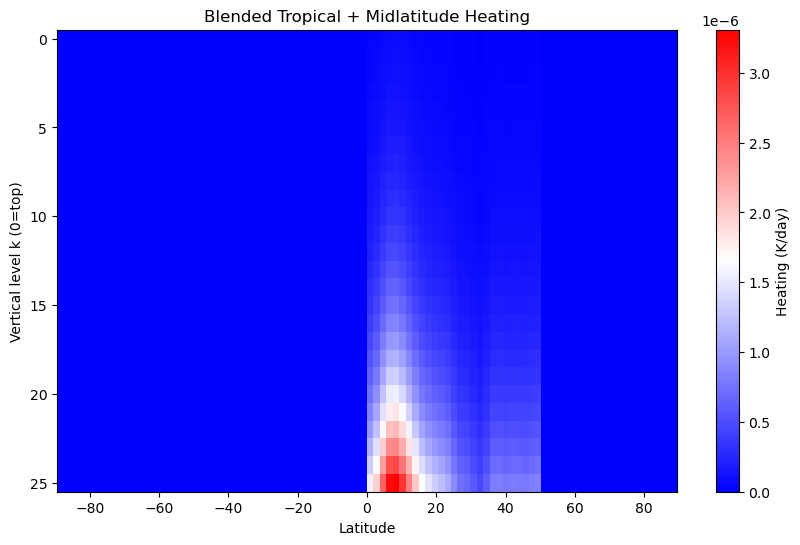

In [25]:
plot_lat_vs_vertical(lats, heat3d, title="Blended Tropical + Midlatitude Heating")

In [26]:
def plot_4cluster_heating_with_profiles(cluster_heat3d_list, w_trop_t, w_mid_t,
                                        vert_trop_t, vert_mid_t, lats,
                                        lat_examples=[0,15,35]):
    """
    Plot 4 clusters with:
    - Actual heating (K/day)
    - Normalized heating (0-1)
    - Dashed lines showing vertical profiles at selected latitudes
    - Overlays of weighted tropical and midlatitude vertical profiles
    - Vertical axis oriented: 0=top, kmax-1=bottom

    Parameters
    ----------
    cluster_heat3d_list : list of torch.Tensor
        List of 3D heating arrays (kmax, nlat, nlon)
    w_trop_t : torch.Tensor (1,nlat,1)
        Tropical latitude weights
    w_mid_t : torch.Tensor (1,nlat,1)
        Midlatitude latitude weights
    vert_trop_t : torch.Tensor (kmax,1,1)
        Tropical vertical profile
    vert_mid_t : torch.Tensor (kmax,1,1)
        Midlatitude vertical profile
    lats : np.ndarray
        Latitude array
    lat_examples : list of float
        Latitudes to overlay profiles
    """
    n_clusters = len(cluster_heat3d_list)
    kmax = cluster_heat3d_list[0].shape[0]

    # Correct vertical levels: 0=top, kmax-1=bottom
    k_levels = np.arange(kmax-1, -1, -1)

    fig, axs = plt.subplots(n_clusters, 2, figsize=(14, 3*n_clusters),
                            sharex=True, sharey=True)

    for i, heat3d in enumerate(cluster_heat3d_list):
        heat_mean = heat3d.mean(dim=2).numpy()  # mean over longitude

        # --- Left: actual heating ---
        im = axs[i,0].pcolormesh(lats, k_levels, heat_mean, shading='auto', cmap='bwr')
        axs[i,0].set_ylabel("Vertical level k (0=top)")
        axs[i,0].set_title(f"Cluster {i}: Actual heating")
        plt.colorbar(im, ax=axs[i,0], label="Heating (K/day)")

        # Overlay dashed lines at selected latitudes
        for lat_val in lat_examples:
            lat_idx = np.argmin(np.abs(lats - lat_val))
            axs[i,0].plot([lat_val]*kmax, k_levels, '--', color='k', alpha=0.7)

        # --- Right: normalized heating ---
        max_val = heat_mean.max(axis=0, keepdims=True)
        max_val[max_val==0] = 1.0
        heat_norm = heat_mean / max_val
        im2 = axs[i,1].pcolormesh(lats, k_levels, heat_norm, shading='auto', cmap='bwr')
        axs[i,1].set_title(f"Cluster {i}: Normalized vertical structure")
        plt.colorbar(im2, ax=axs[i,1], label="Normalized (0-1)")

        # Overlay dashed lines and weighted vertical profiles
        for lat_val in lat_examples:
            lat_idx = np.argmin(np.abs(lats - lat_val))

            # Weighted tropical and midlatitude profiles
            w_t = w_trop_t[0, lat_idx, 0].item()
            w_m = w_mid_t[0, lat_idx, 0].item()
            trop_profile = vert_trop_t[:,0,0].numpy() * w_t
            mid_profile = vert_mid_t[:,0,0].numpy() * w_m

            # Scale profiles to normalized plot
            trop_profile_norm = trop_profile / max_val[0, lat_idx]
            mid_profile_norm = mid_profile / max_val[0, lat_idx]

            axs[i,1].plot([lat_val]*kmax, k_levels, '--', color='k', alpha=0.7)
            axs[i,1].plot([lat_val]*kmax, k_levels, color='orange', alpha=0.8, label="Tropics" if lat_val==lat_examples[0] else "")
            axs[i,1].plot([lat_val]*kmax, k_levels, color='green', alpha=0.8, label="Midlat" if lat_val==lat_examples[0] else "")

    axs[-1,0].set_xlabel("Latitude")
    axs[-1,1].set_xlabel("Latitude")
    handles, labels = axs[-1,1].get_legend_handles_labels()
    if handles:
        axs[-1,1].legend()
    plt.tight_layout()
    plt.show()


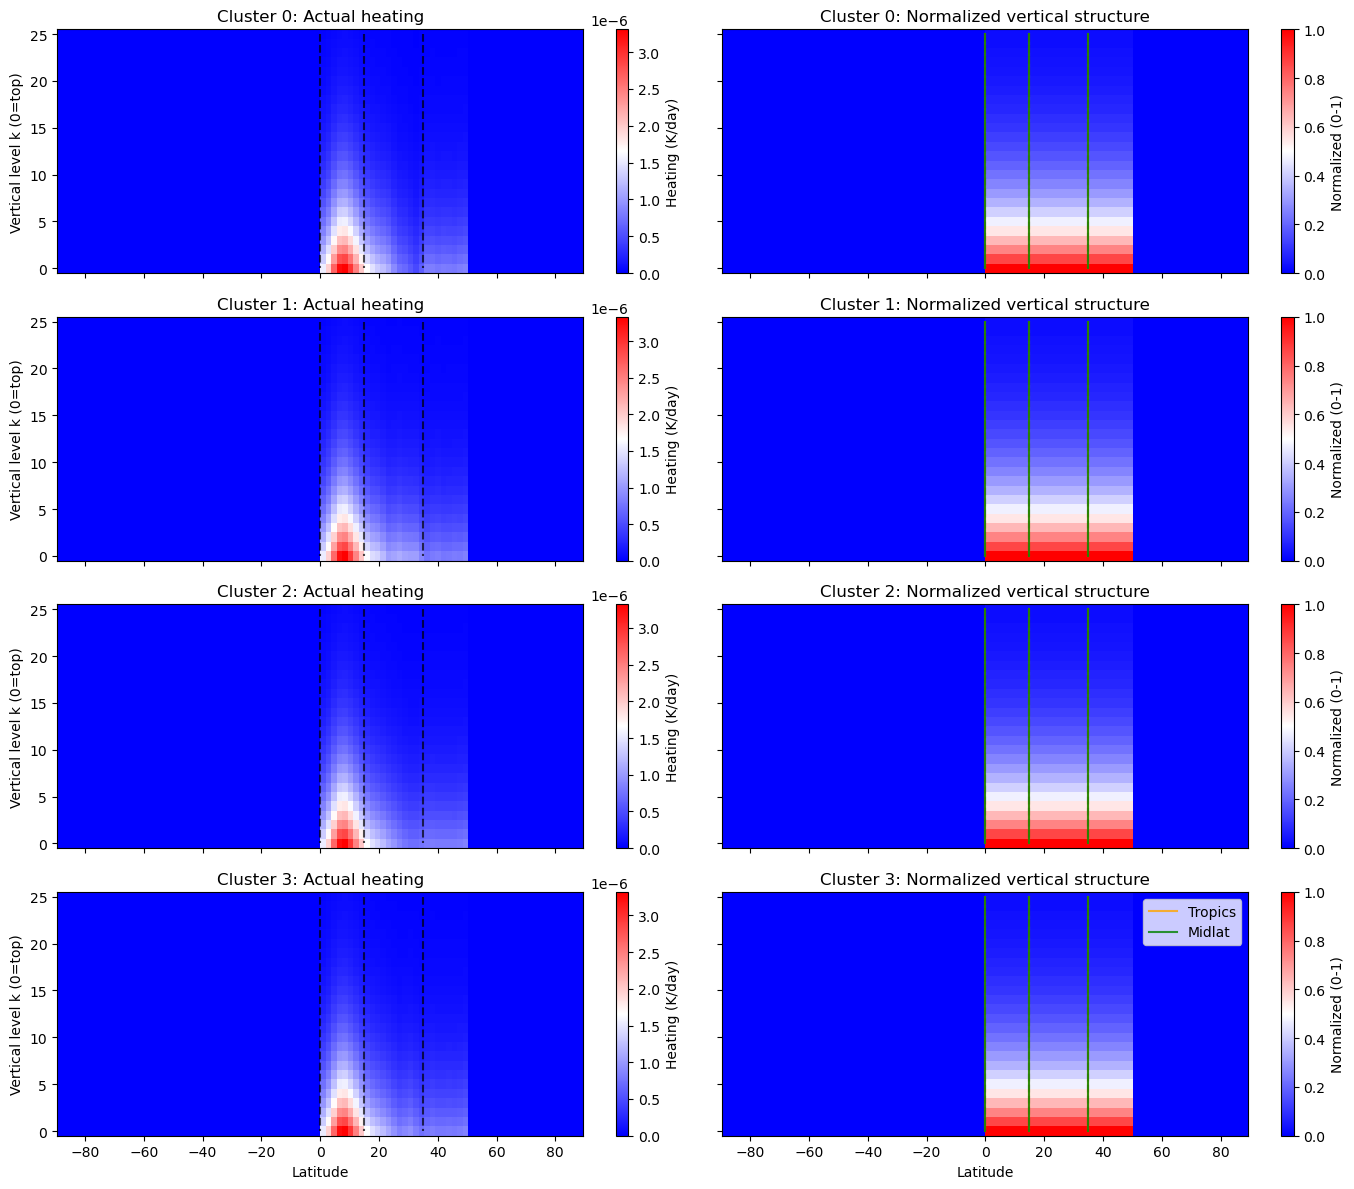

In [27]:
plot_4cluster_heating_with_profiles(cluster_heat3d_list,
                                    w_trop_t, w_mid_t,
                                    vert_trop_t, vert_mid_t,
                                    lats=dlatlon['lat'].values,
                                    lat_examples=[0,15,35])


for c,filestub in zip(cluster_heat3d_list,cluster_filestub):
    ofname=fullpath+'heat.ggrid_'+filestub+'.pt'
    torch.save(c,ofname)